In [ ]:
# ── Cell 1: Setup ─────────────────────────────────────
!pip install kaggle -q

from google.colab import files
files.upload()  # kaggle.json upload

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -q skin-cancer-mnist-ham10000.zip -d ham10000
print(" Dataset ready!")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:45<00:00, 123MB/s]

 Dataset ready!


In [ ]:
import os, shutil, random
import numpy as np
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau)
from sklearn.metrics import classification_report, confusion_matrix

print(f" TensorFlow: {tf.__version__}")

 TensorFlow: 2.19.0


In [ ]:
# ── Cell 3: Organize 3 classes ────────────────────────
# Clear old data
for p in ['/content/dataset', '/content/dataset_balanced']:
    if os.path.exists(p):
        shutil.rmtree(p)

# 3 classes मात्र!
DISEASE_MAP = {
    'nv':  'melanocytic_nevus',   # 6705
    'mel': 'melanoma',            # 1113
    'bkl': 'benign_keratosis',    # 1099
}

OUTPUT_PATH = '/content/dataset'
for cls in DISEASE_MAP.values():
    os.makedirs(os.path.join(OUTPUT_PATH, cls), exist_ok=True)

CSV_PATH = '/content/ham10000/HAM10000_metadata.csv'
IMG_DIR1 = '/content/ham10000/ham10000_images_part_1'
IMG_DIR2 = '/content/ham10000/ham10000_images_part_2'

df = pd.read_csv(CSV_PATH)
copied = 0

for _, row in df.iterrows():
    dx = row['dx']
    if dx not in DISEASE_MAP:
        continue
    img_name = row['image_id'] + '.jpg'
    cls = DISEASE_MAP[dx]
    for d in [IMG_DIR1, IMG_DIR2]:
        src = os.path.join(d, img_name)
        if os.path.exists(src):
            shutil.copy2(
                src,
                os.path.join(OUTPUT_PATH, cls, img_name))
            copied += 1
            break

print(f" Copied: {copied} images")
print("\n Dataset count:")
for cls in sorted(os.listdir(OUTPUT_PATH)):
    n = len(os.listdir(os.path.join(OUTPUT_PATH, cls)))
    bar = '█' * (n // 200)
    print(f"  {cls:<25} {n:>5}  {bar}")

 Copied: 8917 images

 Dataset count:
  benign_keratosis           1099  █████
  melanocytic_nevus          6705  █████████████████████████████████
  melanoma                   1113  █████


In [ ]:
# ── Cell 5: Balance to 1099 ───────────────────────────
BALANCED_PATH = '/content/dataset_balanced'
TARGET = 1099  # benign_keratosis  exact count!

os.makedirs(BALANCED_PATH, exist_ok=True)

print(f" Balancing to {TARGET} per class...")
for cls in sorted(os.listdir(OUTPUT_PATH)):
    src = os.path.join(OUTPUT_PATH, cls)
    dst = os.path.join(BALANCED_PATH, cls)
    os.makedirs(dst, exist_ok=True)

    imgs = [f for f in os.listdir(src)
            if f.lower().endswith(('.jpg','.jpeg','.png'))]
    selected = random.sample(imgs, min(len(imgs), TARGET))

    for img in selected:
        shutil.copy2(
            os.path.join(src, img),
            os.path.join(dst, img))
    print(f"   {cls:<25} → {len(selected)}")

print("\n Final balanced:")
print("-" * 40)
for cls in sorted(os.listdir(BALANCED_PATH)):
    n = len(os.listdir(os.path.join(BALANCED_PATH, cls)))
    bar = '█' * (n // 100)
    print(f"  {cls:<25} {n}  {bar}")
print("\n No augmentation needed!")

 Balancing to 1099 per class...
   benign_keratosis          → 1099
   melanocytic_nevus         → 1099
   melanoma                  → 1099

 Final balanced:
----------------------------------------
  benign_keratosis          1099  ██████████
  melanocytic_nevus         1099  ██████████
  melanoma                  1099  ██████████

 No augmentation needed!


In [ ]:
# ── Cell 6: Data Generators ───────────────────────────
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ← KEY!
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.05,
    height_shift_range=0.05,
    fill_mode='nearest',
    validation_split=0.2
)
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ← KEY!
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    BALANCED_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True, seed=42
)
val_gen = val_datagen.flow_from_directory(
    BALANCED_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False, seed=42
)

print(f" Class mapping: {train_gen.class_indices}")
print(f" Train: {train_gen.samples} samples")
print(f" Val:   {val_gen.samples} samples")


Found 2640 images belonging to 3 classes.
Found 657 images belonging to 3 classes.
 Class mapping: {'benign_keratosis': 0, 'melanocytic_nevus': 1, 'melanoma': 2}
 Train: 2640 samples
 Val:   657 samples


In [ ]:
# ── Cell 7: Build MobileNetV2 ─────────────────────────
base = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False  # Phase 1: frozen

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(3, activation='softmax')(x)  # 3 classes!

model = Model(inputs=base.input, outputs=out)
print(f" Model built!")
print(f"   Total params:     {model.count_params():,}")
print(f"   Output classes:   3")
print(f"   Classes: {list(train_gen.class_indices.keys())}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Model built!
   Total params:     2,427,459
   Output classes:   3
   Classes: ['benign_keratosis', 'melanocytic_nevus', 'melanoma']


In [ ]:
# ── Cell 8: Phase 1 — Head training ───────────────────
MODEL_PATH = '/content/drive/MyDrive/detectderm_3class.h5'

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1),
    ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1)
]

print(" Phase 1: Head training (base frozen)...")
h1 = model.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    callbacks=cb1
)

best_p1 = max(h1.history['val_accuracy']) * 100
print(f"\n Phase 1 Best: {best_p1:.2f}%")

 Phase 1: Head training (base frozen)...
Epoch 1/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5588 - loss: 1.1994
Epoch 1: val_accuracy improved from None to 0.63623, saving model to /content/drive/MyDrive/detectderm_3class.h5



Epoch 1: finished saving model to /content/drive/MyDrive/detectderm_3class.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.5966 - loss: 1.0736 - val_accuracy: 0.6362 - val_loss: 0.8021 - learning_rate: 0.0010
Epoch 2/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6940 - loss: 0.7554
Epoch 2: val_accuracy improved from 0.63623 to 0.66058, saving model to /content/drive/MyDrive/detectderm_3class.h5



Epoch 2: finished saving model to /content/drive/MyDrive/detectderm_3class.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.6917 - loss: 0.7663 - val_accuracy: 0.6606 - val_loss: 0.7858 - learning_rate: 0.0010
Epoch 3/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7467 - loss: 0.6456
Epoch 3: val_accuracy improved from 0.66058 to 0.66667, saving model to /content/drive/MyDrive/detectderm_3class.h5



Epoch 3: finished saving model to /content/drive/MyDrive/detectderm_3class.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.7402 - loss: 0.6504 - val_accuracy: 0.6667 - val_loss: 0.7723 - learning_rate: 0.0010
Epoch 4/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7592 - loss: 0.5713
Epoch 4: val_accuracy improved from 0.66667 to 0.70015, saving model to /content/drive/MyDrive/detectderm_3class.h5



Epoch 4: finished saving model to /content/drive/MyDrive/detectderm_3class.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.7515 - loss: 0.5984 - val_accuracy: 0.7002 - val_loss: 0.7753 - learning_rate: 0.0010
Epoch 5/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7767 - loss: 0.5063
Epoch 5: val_accuracy did not improve from 0.70015
83/83 ━━━━━━━━━━━━━━━━━━━━ 208s 3s/step - accuracy: 0.7693 - loss: 0.5404 - val_accuracy: 0.6986 - val_loss: 0.7771 - learning_rate: 0.0010
Epoch 6/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7714 - loss: 0.5260
Epoch 6: val_accuracy improved from 0.70015 to 0.70320, saving model to /content/drive/MyDrive/detectderm_3class.h5



Epoch 6: finished saving model to /content/drive/MyDrive/detectderm_3class.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.7780 - loss: 0.5207 - val_accuracy: 0.7032 - val_loss: 0.8070 - learning_rate: 0.0010
Epoch 7/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7799 - loss: 0.4898
Epoch 7: val_accuracy did not improve from 0.70320

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
83/83 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.7795 - loss: 0.5058 - val_accuracy: 0.6636 - val_loss: 0.8603 - learning_rate: 0.0010
Epoch 8/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8245 - loss: 0.4486
Epoch 8: val_accuracy did not improve from 0.70320
83/83 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.8167 - loss: 0.4386 - val_accuracy: 0.6956 - val_loss: 0.7753 - learning_rate: 5.0000e-04
Epoch 9/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8266 - loss: 0.4297
Epoch 9: val_accuracy improved from 0.70320 to 0.70472, saving model 


Epoch 9: finished saving model to /content/drive/MyDrive/detectderm_3class.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.8409 - loss: 0.4026 - val_accuracy: 0.7047 - val_loss: 0.7846 - learning_rate: 5.0000e-04
Epoch 10/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8473 - loss: 0.3763
Epoch 10: val_accuracy did not improve from 0.70472
83/83 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.8364 - loss: 0.3963 - val_accuracy: 0.6865 - val_loss: 0.8341 - learning_rate: 5.0000e-04
Epoch 11/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8480 - loss: 0.3796
Epoch 11: val_accuracy did not improve from 0.70472

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
83/83 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.8360 - loss: 0.3991 - val_accuracy: 0.6880 - val_loss: 0.8225 - learning_rate: 5.0000e-04
Epoch 12/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8563 - loss: 0.3628
Epoch 12: val_accuracy did not improve from 0.70472
83/


Epoch 13: finished saving model to /content/drive/MyDrive/detectderm_3class.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.8614 - loss: 0.3460 - val_accuracy: 0.7078 - val_loss: 0.7818 - learning_rate: 2.5000e-04
Epoch 14/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8815 - loss: 0.3199
Epoch 14: val_accuracy improved from 0.70776 to 0.71994, saving model to /content/drive/MyDrive/detectderm_3class.h5



Epoch 14: finished saving model to /content/drive/MyDrive/detectderm_3class.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.8693 - loss: 0.3373 - val_accuracy: 0.7199 - val_loss: 0.7837 - learning_rate: 2.5000e-04
Epoch 15/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8733 - loss: 0.3335
Epoch 15: val_accuracy did not improve from 0.71994

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
83/83 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.8739 - loss: 0.3248 - val_accuracy: 0.7123 - val_loss: 0.7894 - learning_rate: 2.5000e-04
Epoch 16/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8642 - loss: 0.3257
Epoch 16: val_accuracy did not improve from 0.71994
83/83 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.8712 - loss: 0.3246 - val_accuracy: 0.7078 - val_loss: 0.7899 - learning_rate: 1.2500e-04
Epoch 17/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8859 - loss: 0.3113
Epoch 17: val_accuracy did not improve from 0.71994
83

In [ ]:
# ── Phase 2 — Careful Fine-tuning ─────────────────────
print(f" Phase 1: {best_p1:.1f}% — Fine-tuning!")

base.trainable = True
for layer in base.layers[:-10]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1),
    ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-8,
        verbose=1)
]

print(" Phase 2: Fine-tuning top 10 layers...")
h2 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=cb2
)

best_p2 = max(h2.history['val_accuracy']) * 100
print(f"\n Phase 2 Best: {best_p2:.2f}%")

21/21 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step

 Overall: 71.99%

 Per-class:
  benign_keratosis           79.9%  ███████████████
  melanocytic_nevus          71.7%  ██████████████
  melanoma                   64.4%  ████████████

                   precision    recall  f1-score   support

 benign_keratosis      0.686     0.799     0.738       219
melanocytic_nevus      0.805     0.717     0.758       219
         melanoma      0.681     0.644     0.662       219

         accuracy                          0.720       657
        macro avg      0.724     0.720     0.720       657
     weighted avg      0.724     0.720     0.720       657



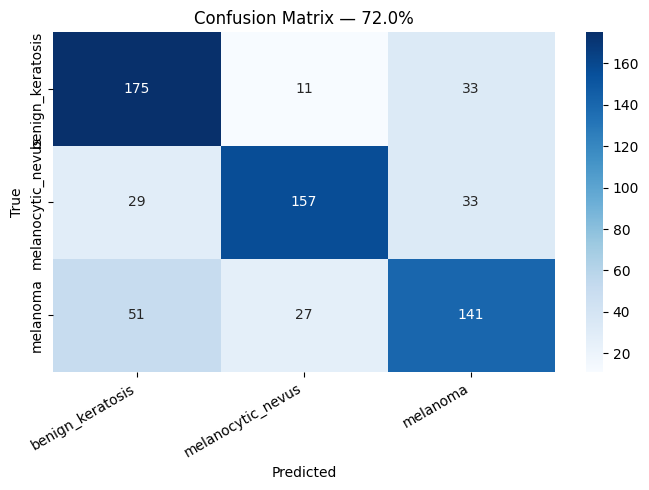

In [ ]:
# ── Evaluate ──────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model = tf.keras.models.load_model(MODEL_PATH)
val_gen.reset()
y_pred = best_model.predict(val_gen, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

overall = np.mean(y_pred_classes == y_true) * 100
print(f"\n Overall: {overall:.2f}%")

print("\n Per-class:")
for i, name in enumerate(class_names):
    mask = y_true == i
    acc = np.mean(y_pred_classes[mask] == y_true[mask]) * 100
    bar = '█' * int(acc // 5)
    print(f"  {name:<25} {acc:>5.1f}%  {bar}")

print("\n" + classification_report(
    y_true, y_pred_classes,
    target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title(f'Confusion Matrix — {overall:.1f}%')
plt.ylabel('True'), plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_final.png',
            dpi=150)
plt.show()

In [ ]:
# ── Real Image Upload + Test ──────────────────────────
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from PIL import Image
from google.colab import files
import io

# ── Load model ────────────────────────────────────────
MODEL_PATH = '/content/drive/MyDrive/detectderm_3class.h5'
model = tf.keras.models.load_model(MODEL_PATH)

CLASS_NAMES = {
    0: 'Benign Keratosis (सामान्य केराटोसिस)',
    1: 'Melanocytic Nevus (तिल)',
    2: 'Melanoma (छाला क्यान्सर)'
}
{'benign_keratosis': 0, 'melanocytic_nevus': 1, 'melanoma': 2}
print(" Model loaded!")
print("\n Image upload गर्नुस्:")

# ── Upload images ─────────────────────────────────────
uploaded = files.upload()

print(f"\n{'='*55}")
print("  PREDICTION RESULTS")
print(f"{'='*55}")

for filename, file_bytes in uploaded.items():
    # Load image
    img = Image.open(io.BytesIO(file_bytes)).convert('RGB')
    img_resized = img.resize((224, 224))

    # Preprocess
    img_array = np.array(img_resized, dtype=np.float32)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array, verbose=0)
    scores = predictions[0]
    pred_class = np.argmax(scores)
    confidence = scores[pred_class] * 100

    # Show result
    print(f"\n📸 File: {filename}")
    print(f"{'─'*55}")
    print(f"  🔬 Predicted: {CLASS_NAMES[pred_class]}")
    print(f"  📊 Confidence: {confidence:.1f}%")

    # Confidence level
    if confidence >= 80:
        level = "🟢 High — Reliable"
    elif confidence >= 60:
        level = "🟡 Moderate — Consult doctor"
    else:
        level = "🔴 Low — Unclear image"
    print(f"  📈 Level: {level}")

    # All class scores
    print(f"\n  All scores:")
    for idx in range(3):
        bar = '█' * int(scores[idx] * 25)
        marker = " ←" if idx == pred_class else ""
        print(f"  {CLASS_NAMES[idx]:<40} "
              f"{scores[idx]*100:>5.1f}%  {bar}{marker}")

    # Warning
    if confidence < 60:
        print(f"\n  ⚠️  Confidence कम छ!")
        print(f"  → राम्रो lighting मा photo खिच्नुस्")
        print(f"  → Affected area नजिकबाट खिच्नुस्")
    elif pred_class == 2:  # Melanoma
        print(f"\n  ⚠️  MELANOMA detected!")
        print(f"  → तुरुन्तै डाक्टरकहाँ जानुस्!")

print(f"\n{'='*55}")
print("  ⚠️  यो AI prediction मात्र हो।")
print("  Final diagnosis को लागि डाक्टर देखाउनुस्!")
print(f"{'='*55}")

 Model loaded!

 Image upload गर्नुस्:


Saving ben.jpg to ben (2).jpg

  PREDICTION RESULTS

📸 File: ben (2).jpg
───────────────────────────────────────────────────────
  🔬 Predicted: Benign Keratosis (सामान्य केराटोसिस)
  📊 Confidence: 99.1%
  📈 Level: 🟢 High — Reliable

  All scores:
  Benign Keratosis (सामान्य केराटोसिस)      99.1%  ████████████████████████ ←
  Melanocytic Nevus (तिल)                    0.4%  
  Melanoma (छाला क्यान्सर)                   0.4%  

  ⚠️  यो AI prediction मात्र हो।
  Final diagnosis को लागि डाक्टर देखाउनुस्!


In [ ]:
# Model Save
from google.colab import drive
drive.mount('/drive')

import shutil
shutil.copy('/content/detectderm_model.h5',
            '/drive/MyDrive/detectderm_model.h5')
print("Model is Saved in Google Drive")

In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/detectderm_3class.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>